# Stage 1: train the intrusion-detection models

Random Forest is the main algorithm. Decision Tree and K-Nearest Neighbors
(KNN) are the comparison models. All three do binary classification:
**benign (0)** or **attack (1)**.

The models read only the twenty features that notebook 00 selected. They
train on `train.parquet` and are measured on the complete `test.parquet`,
which no earlier step has used.

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from tqdm.auto import tqdm

RANDOM_STATE = 42

# None trains Random Forest and Decision Tree on every training row.
TRAIN_SAMPLE_SIZE = None

# KNN keeps every training row in memory and compares each test row with all
# of them. A smaller training sample keeps its running time reasonable.
KNN_TRAINING_ROWS = 25_000

PREDICTION_BATCH_SIZE = 20_000
RUN_TRAINING = True

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_FILE = PROJECT_ROOT / "dataset/processed/train.parquet"
TEST_FILE = PROJECT_ROOT / "dataset/processed/test.parquet"
FEATURE_FILE = PROJECT_ROOT / "artifacts/feature_selection/selected_features.json"
OUTPUT_FOLDER = PROJECT_ROOT / "artifacts/models"

## 1. Load the selected features

In [2]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding="utf-8"))
selected_features = feature_report["selected_features"]
print(f"Using {len(selected_features)} features:")
for number, feature in enumerate(selected_features, 1):
    print(f"{number:2}. {feature}")

Using 20 features:
 1. Packet Length Variance
 2. Packet Length Std
 3. Avg Bwd Segment Size
 4. Bwd Packet Length Std
 5. Average Packet Size
 6. Destination Port
 7. Fwd IAT Max
 8. Fwd IAT Std
 9. Subflow Bwd Bytes
10. Flow IAT Std
11. Fwd Packet Length Max
12. Idle Min
13. Init_Win_bytes_backward
14. Fwd IAT Total
15. Avg Fwd Segment Size
16. Total Length of Fwd Packets
17. Init_Win_bytes_forward
18. Fwd IAT Mean
19. Flow IAT Mean
20. Min Packet Length


## 2. Load the training and test data

Only the selected feature columns and the binary label are read. The optional
training sample is stratified, so it keeps the benign/attack ratio. The
complete test set is always kept.

In [3]:
def sample_training_data(x_train, y_train, sample_size):
    """Return a reproducible stratified sample of the training rows."""
    if sample_size is None or sample_size >= len(x_train):
        return x_train, y_train
    sample_rows, _ = train_test_split(
        np.arange(len(x_train)),
        train_size=sample_size,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
    return x_train.iloc[sample_rows], y_train.iloc[sample_rows]


def load_model_data(features, train_sample_size=None):
    columns = features + ["is_attack"]
    train = pd.read_parquet(TRAIN_FILE, columns=columns)
    test = pd.read_parquet(TEST_FILE, columns=columns)

    x_train, y_train = sample_training_data(
        train[features], train["is_attack"], train_sample_size
    )
    return x_train, y_train, test[features], test["is_attack"]

In [4]:
if RUN_TRAINING:
    x_train, y_train, x_test, y_test = load_model_data(
        selected_features, TRAIN_SAMPLE_SIZE
    )
    print(f"Training rows: {len(x_train):,}")
    print(f"Testing rows:  {len(x_test):,}")
    display(pd.DataFrame({
        "train": y_train.value_counts().rename(index={0: "Benign", 1: "Attack"}),
        "test": y_test.value_counts().rename(index={0: "Benign", 1: "Attack"}),
    }))

Training rows: 1,998,384
Testing rows:  499,596


,train,test
is_attack,,
Benign,1657803,414451
Attack,340581,85145


## 3. Create the models

The attack class is much smaller than the benign class. Balanced class
weights give the attack class more influence, so the models do not learn to
call everything benign. A limited tree depth reduces overfitting.

KNN measures distance, so its input must be on one scale. The KNN pipeline
therefore contains its own `StandardScaler`. The scaler learns from the KNN
training sample only.

In [5]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_leaf=2,
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "K-Nearest Neighbors": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1),
    ),
}
models

{'Random Forest': RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                        min_samples_leaf=2, n_jobs=-1, random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                        min_samples_leaf=2, random_state=42),
 'K-Nearest Neighbors': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('kneighborsclassifier',
                  KNeighborsClassifier(n_jobs=-1, weights='distance'))])}

## 4. Train and evaluate

The prediction runs in batches. This keeps the memory use of KNN low.
For each model the notebook records accuracy, precision, recall, F1-score,
and ROC-AUC, plus the training time and the prediction time.

In [6]:
def predict_in_batches(model, x_test):
    predictions, probabilities = [], []
    positive_class = list(model.classes_).index(1)
    batches = range(0, len(x_test), PREDICTION_BATCH_SIZE)
    for start in tqdm(batches, desc="Predicting", unit="batch"):
        batch = x_test.iloc[start:start + PREDICTION_BATCH_SIZE]
        batch_probabilities = model.predict_proba(batch)
        predictions.append(model.classes_[np.argmax(batch_probabilities, axis=1)])
        probabilities.append(batch_probabilities[:, positive_class])
    return np.concatenate(predictions), np.concatenate(probabilities)


def evaluate_model(model, x_test, y_test):
    start = time.perf_counter()
    predictions, probabilities = predict_in_batches(model, x_test)
    prediction_seconds = time.perf_counter() - start

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1_score": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "prediction_seconds": prediction_seconds,
    }
    return metrics, predictions, probabilities

Training Random Forest with 1,998,384 rows...


Predicting:   0%|          | 0/25 [00:00<?, ?batch/s]

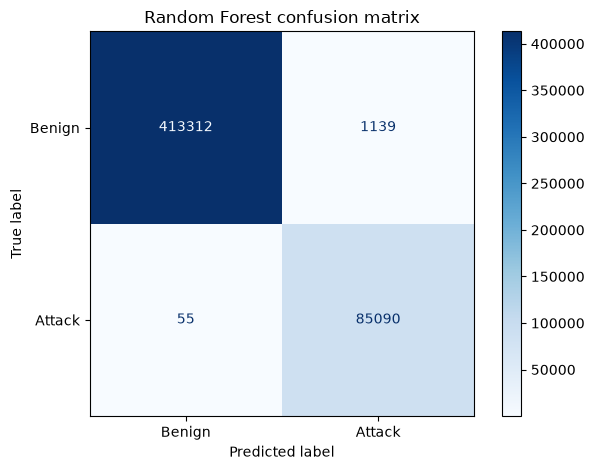

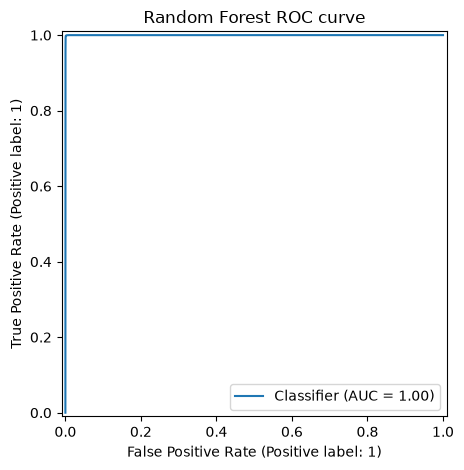

Training Decision Tree with 1,998,384 rows...


Predicting:   0%|          | 0/25 [00:00<?, ?batch/s]

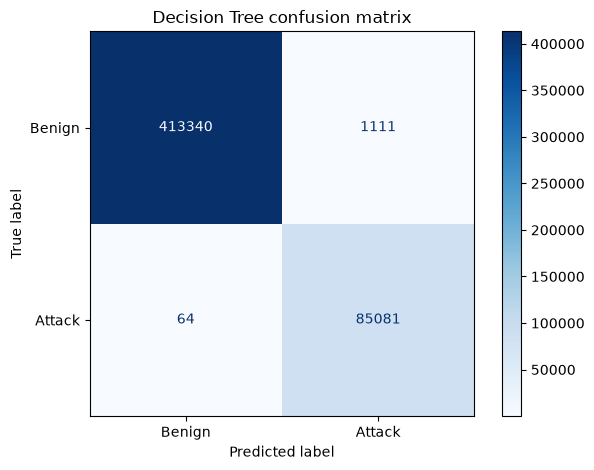

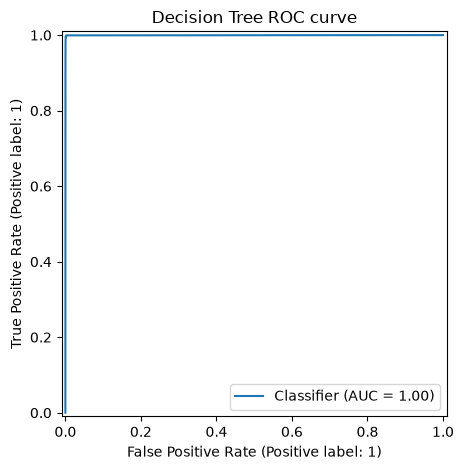

Training K-Nearest Neighbors with 25,000 rows...


Predicting:   0%|          | 0/25 [00:00<?, ?batch/s]

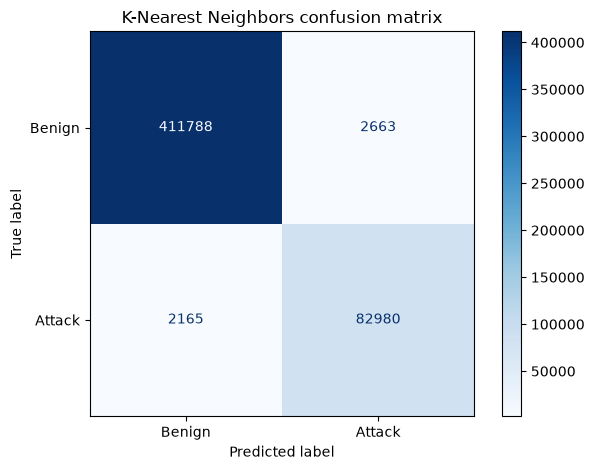

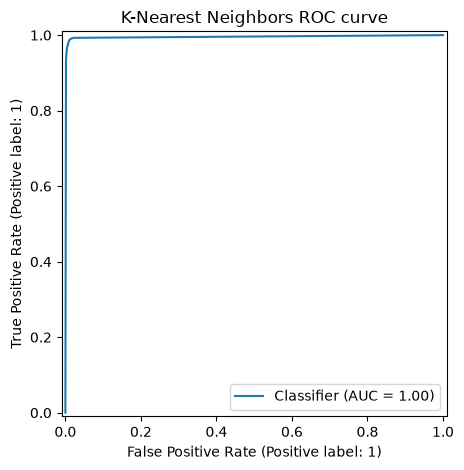

,accuracy,precision,recall,f1_score,roc_auc,prediction_seconds,training_rows,testing_rows,training_seconds
model,,,,,,,,,
Random Forest,0.9976,0.9868,0.9994,0.9930,1.0000,2.8967,1998384,499596,165.0709
Decision Tree,0.9976,0.9871,0.9992,0.9931,0.9995,0.1412,1998384,499596,65.4378
K-Nearest Neighbors,0.9903,0.9689,0.9746,0.9717,0.9954,43.4739,25000,499596,0.0262


In [7]:
if RUN_TRAINING:
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
    results = []
    model_predictions = {}

    for model_name, model in models.items():
        model_x_train, model_y_train = x_train, y_train
        if model_name == "K-Nearest Neighbors":
            model_x_train, model_y_train = sample_training_data(
                x_train, y_train, KNN_TRAINING_ROWS
            )

        print(f"Training {model_name} with {len(model_x_train):,} rows...")
        start = time.perf_counter()
        model.fit(model_x_train, model_y_train)
        training_seconds = time.perf_counter() - start

        metrics, predictions, probabilities = evaluate_model(model, x_test, y_test)
        metrics.update({
            "model": model_name,
            "training_rows": len(model_x_train),
            "testing_rows": len(x_test),
            "training_seconds": training_seconds,
        })
        results.append(metrics)
        model_predictions[model_name] = (predictions, probabilities)

        file_name = model_name.lower().replace(" ", "_")
        joblib.dump(model, OUTPUT_FOLDER / f"{file_name}.joblib")

        ConfusionMatrixDisplay.from_predictions(
            y_test, predictions, display_labels=["Benign", "Attack"], cmap="Blues"
        )
        plt.title(f"{model_name} confusion matrix")
        plt.tight_layout()
        plt.savefig(OUTPUT_FOLDER / f"{file_name}_confusion_matrix.png", dpi=150)
        plt.show()

        RocCurveDisplay.from_predictions(y_test, probabilities)
        plt.title(f"{model_name} ROC curve")
        plt.tight_layout()
        plt.savefig(OUTPUT_FOLDER / f"{file_name}_roc_curve.png", dpi=150)
        plt.show()

    results = pd.DataFrame(results).set_index("model")
    results.to_csv(OUTPUT_FOLDER / "model_results.csv")
    display(results.round(4))

## 5. Comparison table

This is the table that the project description asks for.

In [8]:
def markdown_table(frame):
    """Build a Markdown table without an extra library."""
    columns = [frame.index.name or ""] + [str(column) for column in frame.columns]
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for name, row in zip(frame.index, frame.to_numpy()):
        cells = [str(name)] + [f"{value:.4f}" for value in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


if RUN_TRAINING:
    comparison = results[["accuracy", "precision", "recall", "f1_score"]].round(4)
    comparison.columns = ["Accuracy", "Precision", "Recall", "F1-score"]
    display(comparison)
    print(markdown_table(comparison))

,Accuracy,Precision,Recall,F1-score
model,,,,
Random Forest,0.9976,0.9868,0.9994,0.9930
Decision Tree,0.9976,0.9871,0.9992,0.9931
K-Nearest Neighbors,0.9903,0.9689,0.9746,0.9717


| model | Accuracy | Precision | Recall | F1-score |
| --- | --- | --- | --- | --- |
| Random Forest | 0.9976 | 0.9868 | 0.9994 | 0.9930 |
| Decision Tree | 0.9976 | 0.9871 | 0.9992 | 0.9931 |
| K-Nearest Neighbors | 0.9903 | 0.9689 | 0.9746 | 0.9717 |


In [9]:
if RUN_TRAINING:
    for model_name, (predictions, _) in model_predictions.items():
        print(f"\n{model_name}")
        print(classification_report(
            y_test, predictions, target_names=["Benign", "Attack"], digits=4,
            zero_division=0,
        ))


Random Forest


              precision    recall  f1-score   support

      Benign     0.9999    0.9973    0.9986    414451
      Attack     0.9868    0.9994    0.9930     85145

    accuracy                         0.9976    499596
   macro avg     0.9933    0.9983    0.9958    499596
weighted avg     0.9976    0.9976    0.9976    499596


Decision Tree


              precision    recall  f1-score   support

      Benign     0.9998    0.9973    0.9986    414451
      Attack     0.9871    0.9992    0.9931     85145

    accuracy                         0.9976    499596
   macro avg     0.9935    0.9983    0.9959    499596
weighted avg     0.9977    0.9976    0.9977    499596


K-Nearest Neighbors


              precision    recall  f1-score   support

      Benign     0.9948    0.9936    0.9942    414451
      Attack     0.9689    0.9746    0.9717     85145

    accuracy                         0.9903    499596
   macro avg     0.9818    0.9841    0.9830    499596
weighted avg     0.9904    0.9903    0.9903    499596



## 6. Save the training report

In [10]:
if RUN_TRAINING:
    training_report = {
        "main_model": "Random Forest",
        "task": "binary classification (benign or attack)",
        "random_state": RANDOM_STATE,
        "selected_features": selected_features,
        "training_sample_size": TRAIN_SAMPLE_SIZE,
        "knn_training_rows": KNN_TRAINING_ROWS,
        "results": results.reset_index().to_dict(orient="records"),
    }
    (OUTPUT_FOLDER / "training_report.json").write_text(
        json.dumps(training_report, indent=2), encoding="utf-8"
    )
    print("Models and results saved in artifacts/models")

Models and results saved in artifacts/models


## 7. View saved results

In [11]:
result_file = OUTPUT_FOLDER / "model_results.csv"
if result_file.exists():
    saved_results = pd.read_csv(result_file, index_col="model")
    display(saved_results.round(4))
else:
    print("Set RUN_TRAINING = True and run the training cells.")

,accuracy,precision,recall,f1_score,roc_auc,prediction_seconds,training_rows,testing_rows,training_seconds
model,,,,,,,,,
Random Forest,0.9976,0.9868,0.9994,0.9930,1.0000,2.8967,1998384,499596,165.0709
Decision Tree,0.9976,0.9871,0.9992,0.9931,0.9995,0.1412,1998384,499596,65.4378
K-Nearest Neighbors,0.9903,0.9689,0.9746,0.9717,0.9954,43.4739,25000,499596,0.0262


## Notes

- Random Forest is the main model of the system.
- Decision Tree shows what one tree can do; Random Forest joins 100 trees.
- KNN trains on a smaller sample, so its numbers are not a fair speed comparison with the other two.
- The test set is used for the final measurement only.
- Accuracy alone can hide missed attacks, because most flows are benign. Recall shows how many attacks the model found.